Kelas: ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']
[audioanjing] 89 file
[audiobabi] 103 file
[audiobajingan] 128 file
[audiobangsat] 132 file
[audiogoblok] 137 file
[audiojancuk] 122 file
[audiotai] 98 file
[audiotolol] 114 file
Fitur per frame: 120, max_len (p95): 2587, num_classes: 8
Class weights: {0: 1.2992957746478873, 1: 1.125, 2: 0.9044117647058824, 3: 0.8702830188679245, 4: 0.8386363636363636, 5: 0.9413265306122449, 6: 1.1826923076923077, 7: 1.0137362637362637}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 2587, 120)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 2587, 120)         │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ masking (Masking)             │ (None, 2587, 120)         │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ any (Any)                     │ (None, 2587)              │               0 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 2587, 256)         │         254,976 │ masking[0][0], any[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_1               │ (None, 128)               │         164,352 │ bidirectional[0][0],       │
│ (Bidirectional)               │                           │                 │ any[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          16,512 │ bidirectional_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │           1,032 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 436,872 (1.67 MB)

 Trainable params: 436,872 (1.67 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 144s/step - accuracy: 0.1566 - loss: 2.1047  
Epoch 1: val_loss improved from None to 2.08248, saving model to best_rnn_mfcc.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3508s 145s/step - accuracy: 0.1545 - loss: 2.1032 - val_accuracy: 0.1838 - val_loss: 2.0825 - learning_rate: 0.0010
Epoch 2/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 145s/step - accuracy: 0.1927 - loss: 2.0440  
Epoch 2: val_loss improved from 2.08248 to 2.07162, saving model to best_rnn_mfcc.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3496s 146s/step - accuracy: 0.1843 - loss: 2.0601 - val_accuracy: 0.1784 - val_loss: 2.0716 - learning_rate: 0.0010
Epoch 3/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 146s/step - accuracy: 0.2305 - loss: 2.0075  
Epoch 3: val_loss improved from 2.07162 to 2.06290, saving model to best_rnn_mfcc.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 3520s 147s/step - accuracy: 0.2222 - loss: 2.0076 - val_accuracy: 0.2108 - val_loss: 2.0629 - learning_rate: 0.0010
Epoch 4/150
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 149s

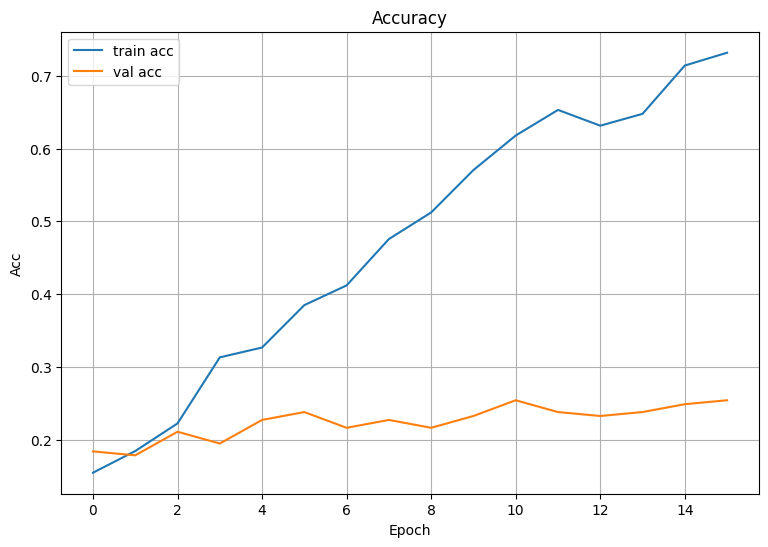

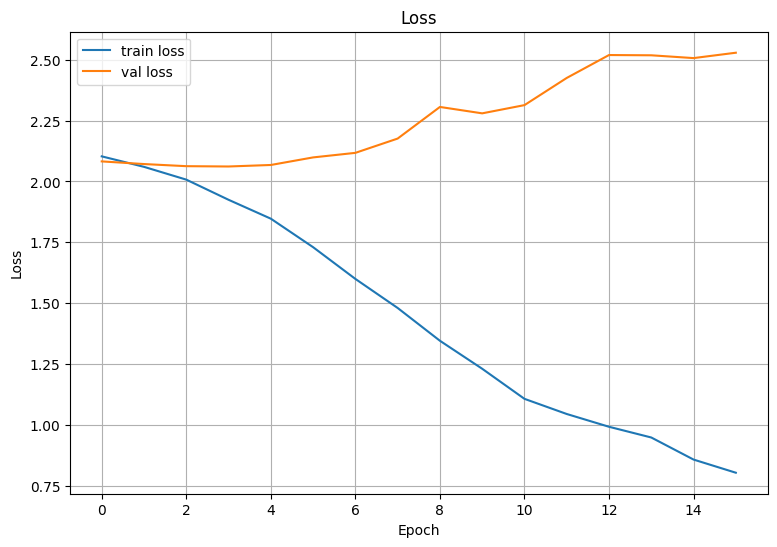

In [1]:
# =========================
# RNN (BiLSTM) untuk MFCC
# =========================
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from pathlib import Path
import librosa

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers

# -------- Konfigurasi --------
DATA_DIR   = r"D:\web\cnn_clasification\archive\Data\genres_original"  # ganti
SUBDIR     = ""             # "" jika kelas = subfolder, atau isi "audioanjing" untuk 1 folder kelas
SR         = 22050
N_MFCC     = 40
HOP        = 512
DURATION   = None           # None = full file; atau set durasi (detik), mis. 5.0
SEED       = 42
PCTL_MAX   = 95             # panjang urutan dipotong di persentil ini agar padding tidak kebangetan

np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# -------- Util Audio/Feature --------
def load_audio(path, sr=SR, duration=DURATION):
    y, sr = librosa.load(path, sr=sr, duration=duration, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    return y, sr

def mfcc_sequence(y, sr, n_mfcc=N_MFCC, hop=HOP):
    """
    Return shape: (T, F) dengan F = n_mfcc * 3 (mfcc, delta, delta2 disatukan di dimensi fitur)
    """
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, hop_length=hop)        # (n_mfcc, T)
    d1   = librosa.feature.delta(mfcc)
    d2   = librosa.feature.delta(mfcc, order=2)
    feat = np.concatenate([mfcc, d1, d2], axis=0)  # (3*n_mfcc, T)
    return feat.T.astype(np.float32)               # (T, 3*n_mfcc)

def list_audio_files(root, exts=(".wav", ".mp3", ".flac", ".ogg", ".m4a", ".WAV", ".MP3", ".FLAC")):
    root = Path(root)
    out = []
    for p in sorted(root.rglob("*")):
        if p.suffix in exts and p.is_file():
            out.append(p)
    return out

def build_dataset_from_dir(data_dir, subdir=""):
    X_seq, y, paths = [], [], []
    data_root = Path(data_dir)
    if subdir:
        # satu kelas (semua file dalam subdir)
        class_names = [subdir]
        files = list_audio_files(data_root / subdir)
        print(f"Menemukan {len(files)} file di {data_root/subdir}")
        for f in files:
            try:
                ysig, sr = load_audio(str(f))
                X_seq.append(mfcc_sequence(ysig, sr))
                y.append(0)
                paths.append(str(f))
            except Exception as e:
                print("Gagal:", f, e)
    else:
        # multi-kelas: nama subfolder = label
        class_names = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
        print("Kelas:", class_names)
        for ci, cname in enumerate(class_names):
            files = list_audio_files(data_root / cname)
            print(f"[{cname}] {len(files)} file")
            for f in files:
                try:
                    ysig, sr = load_audio(str(f))
                    X_seq.append(mfcc_sequence(ysig, sr))
                    y.append(ci)
                    paths.append(str(f))
                except Exception as e:
                    print("Gagal:", f, e)
    return X_seq, np.array(y, dtype=np.int64), class_names, np.array(paths)

# -------- Muat data (urutan) --------
X_seq, y, class_names, paths = build_dataset_from_dir(DATA_DIR, SUBDIR)
num_classes = int(np.max(y)) + 1
feat_dim = X_seq[0].shape[1]
lengths = np.array([s.shape[0] for s in X_seq])
max_len = int(np.percentile(lengths, PCTL_MAX))
max_len = max(16, max_len)  # keamanan
print(f"Fitur per frame: {feat_dim}, max_len (p{PCTL_MAX}): {max_len}, num_classes: {num_classes}")

# -------- Padding/Truncate ke panjang seragam --------
def pad_or_truncate(seq, max_len):
    T, F = seq.shape
    if T >= max_len:
        return seq[:max_len, :]
    out = np.zeros((max_len, F), dtype=np.float32)
    out[:T, :] = seq
    return out

X_pad = np.stack([pad_or_truncate(s, max_len) for s in X_seq], axis=0)  # (N, max_len, F)

# -------- Split (stratified) --------
X_train, X_val, y_train, y_val = train_test_split(
    X_pad, y, test_size=0.2, stratify=y, random_state=SEED
)

# -------- Standardisasi fitur per-frame (fit hanya di frame valid training) --------
# Ambil seluruh frame valid (tanpa padding) dari training untuk fit scaler
valid_frames = []
for s, orig_len in zip(X_train, np.minimum(lengths[:len(X_train)], max_len)):
    valid_frames.append(s[:orig_len, :])
valid_frames = np.concatenate(valid_frames, axis=0)  # (sum_T, F)

scaler = StandardScaler()
scaler.fit(valid_frames)

# Transform semua sequence
def transform_seq_batch(X):
    N, T, F = X.shape
    Xr = X.reshape(-1, F)
    Xr = scaler.transform(Xr)
    return Xr.reshape(N, T, F).astype(np.float32)

X_train_s = transform_seq_batch(X_train)
X_val_s   = transform_seq_batch(X_val)

# -------- Class weight (jika tidak seimbang) --------
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=y_train
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_arr)}
print("Class weights:", class_weights)

# -------- Model RNN (BiLSTM) --------
def build_bilstm(input_timesteps, input_features, num_classes):
    inp = layers.Input(shape=(input_timesteps, input_features))
    x   = layers.Masking(mask_value=0.0)(inp)  # menghormati padding

    # Blok RNN
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
        )(x)
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)
        )(x)

    # Head klasifikasi
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inp, out)

model = build_bilstm(max_len, feat_dim, num_classes)
model.summary()

# -------- Compile --------
opt = optimizers.Adam(learning_rate=1e-3)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -------- Callbacks --------
cbs = [
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('best_rnn_mfcc.keras', monitor='val_loss', save_best_only=True, verbose=1),
]

# -------- Train --------
hist = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1
)

# -------- Evaluasi --------
y_val_prob = model.predict(X_val_s)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=class_names, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_val, y_val_pred))

# -------- Plot training --------
import matplotlib.pyplot as plt

def plot_history(h):
    plt.figure(figsize=(9,6))
    plt.plot(h.history['accuracy'], label='train acc')
    plt.plot(h.history['val_accuracy'], label='val acc')
    plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Acc'); plt.grid(True); plt.legend(); plt.show()

    plt.figure(figsize=(9,6))
    plt.plot(h.history['loss'], label='train loss')
    plt.plot(h.history['val_loss'], label='val loss')
    plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(True); plt.legend(); plt.show()

plot_history(hist)
